In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../data/processed/power_unit_telemetry_clean.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,timestamp,test_id,rpm,torque,power_output,engine_temperature,oil_temperature,oil_pressure,coolant_temperature,fuel_flow,battery_voltage,battery_current,motor_temperature,vibration,ambient_temperature,oil_pressure_missing_flag,battery_voltage_missing_flag,rpm_invalid_flag,oil_pressure_invalid_flag
0,2026-01-01 00:00:00.000,52,9170.908064,410.370614,395.059451,118.890588,115.722447,5.004577,92.018159,100.244429,692.603422,242.082972,70.505266,0.474026,21.300203,False,False,False,False
1,2026-01-01 00:00:00.100,93,8741.371628,401.304408,368.660043,118.950760,109.456450,5.025668,90.155489,98.595513,716.305722,221.882882,73.017445,0.431022,18.508320,False,False,False,False
2,2026-01-01 00:00:00.200,15,12424.126136,505.108925,657.222082,134.455566,127.941860,5.062583,97.645027,110.461699,700.963075,247.667492,72.668806,0.580040,21.237768,False,False,False,False
3,2026-01-01 00:00:00.300,72,10232.921758,432.383144,466.166635,124.329492,115.685712,4.961642,94.054332,102.087132,701.989977,284.083749,74.502698,0.499186,18.974599,False,False,False,False
4,2026-01-01 00:00:00.400,61,10476.270500,429.838796,467.645926,120.171484,110.123562,4.765619,95.648271,101.240923,698.750928,278.236767,74.388367,0.452309,22.602535,False,False,False,False


In [3]:
df.shape

(500000, 19)

In [4]:
df.info

<bound method DataFrame.info of                       timestamp  test_id           rpm      torque  \
0       2026-01-01 00:00:00.000       52   9170.908064  410.370614   
1       2026-01-01 00:00:00.100       93   8741.371628  401.304408   
2       2026-01-01 00:00:00.200       15  12424.126136  505.108925   
3       2026-01-01 00:00:00.300       72  10232.921758  432.383144   
4       2026-01-01 00:00:00.400       61  10476.270500  429.838796   
...                         ...      ...           ...         ...   
499995  2026-01-01 13:53:19.500       55   6967.910448  403.741014   
499996  2026-01-01 13:53:19.600       48   8026.954215  410.486300   
499997  2026-01-01 13:53:19.700       20   7650.903075  424.209520   
499998  2026-01-01 13:53:19.800       14  10513.287622  463.433710   
499999  2026-01-01 13:53:19.900       33   5277.949887  342.826109   

        power_output  engine_temperature  oil_temperature  oil_pressure  \
0         395.059451          118.890588       115.7

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
test_id,500000.0,50.477622,28.887035,1.000000,25.000000,50.000000,76.000000,100.000000
rpm,499900.0,9495.105228,1797.335900,3000.000000,8280.167612,9499.915596,10710.042574,15000.000000
torque,500000.0,427.393711,36.731388,257.934389,402.689801,427.413878,452.252658,600.034049
power_output,500000.0,430.053428,110.424243,87.664915,352.683040,424.456558,501.332912,905.545716
engine_temperature,500000.0,120.153164,5.756276,95.782593,116.278425,120.161554,124.054806,145.718370
oil_temperature,500000.0,112.150782,6.096012,86.366703,108.040656,112.155238,116.271733,138.070319
oil_pressure,498950.0,4.998310,0.119926,4.456893,4.917382,4.998100,5.079378,5.552029
coolant_temperature,500000.0,92.094474,3.802984,74.662458,89.525652,92.097174,94.672602,108.676556
fuel_flow,500000.0,98.991765,4.118268,80.569068,96.215381,98.991184,101.777398,116.007349
battery_voltage,499499.0,699.998435,7.993355,662.154740,694.582069,700.017147,705.395990,738.438358


In [6]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)

)

missing[missing > 0]


oil_pressure       1050
battery_voltage     501
rpm                 100
dtype: int64

In [8]:
missing_pct = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_pct[missing_pct > 0]

oil_pressure       0.2100
battery_voltage    0.1002
rpm                0.0200
dtype: float64

How does power output behave as RPM increases gradually ?

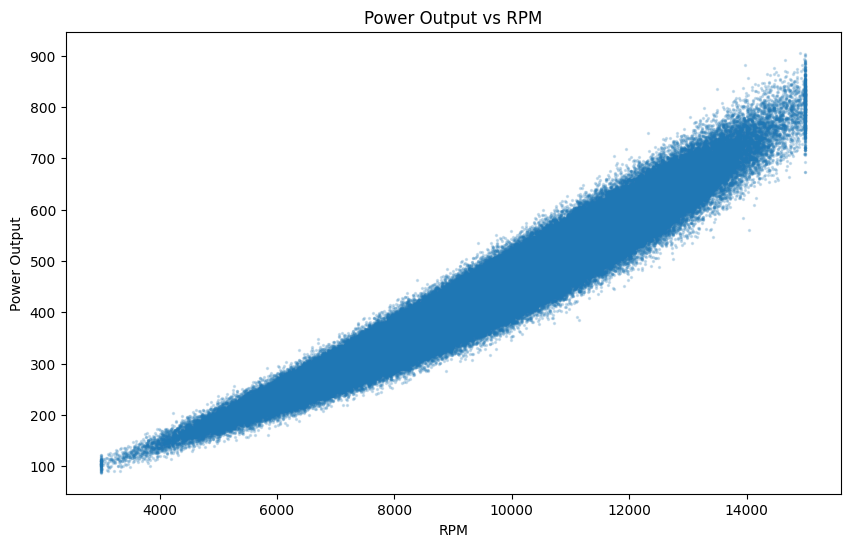

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["rpm"],
    df["power_output"],
    s=2,
    alpha=0.2
)

plt.xlabel("RPM")
plt.ylabel("Power Output")
plt.title("Power Output vs RPM")

plt.show()

Now calculating Correlation

In [10]:
df[["rpm", "power_output"]].corr()

,rpm,power_output
rpm,1.000000,0.970317
power_output,0.970317,1.000000


Pearson vs Spearman analysis

In [11]:
# calculating pearson 

pearson = df[
    ["rpm", "power_output"]
].corr(method="pearson")

pearson

,rpm,power_output
rpm,1.000000,0.970317
power_output,0.970317,1.000000


In [12]:
#calculating spearman

spearman = df[
    ["rpm", "power_output"]
].corr(method="spearman")

spearman

,rpm,power_output
rpm,1.000000,0.970618
power_output,0.970618,1.000000


Now Analysing the thermal system in the car 

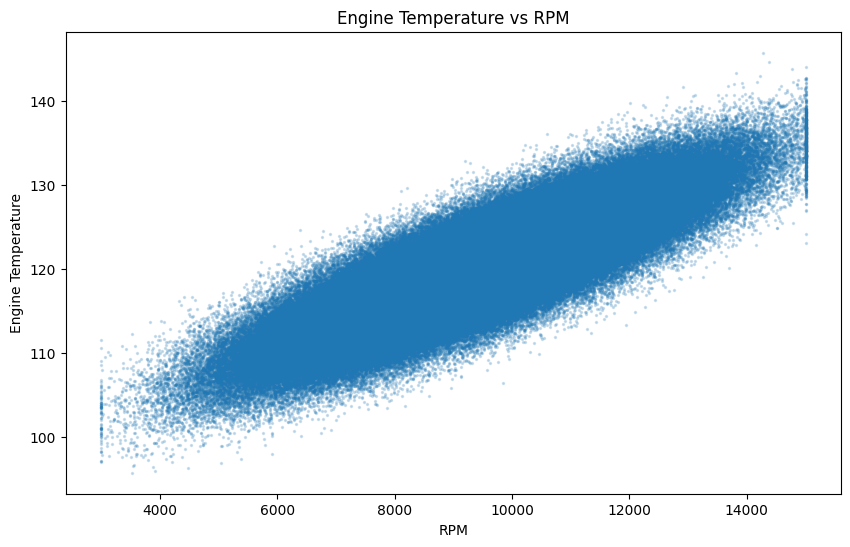

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["rpm"],
    df["engine_temperature"],
    s=2,
    alpha=0.2
)

plt.xlabel("RPM")
plt.ylabel("Engine Temperature")
plt.title("Engine Temperature vs RPM")

plt.show()

In [14]:
df[
    ["rpm", "engine_temperature"]
].corr()

,rpm,engine_temperature
rpm,1.000000,0.850992
engine_temperature,0.850992,1.000000


Inspecting oil pressure in the car 

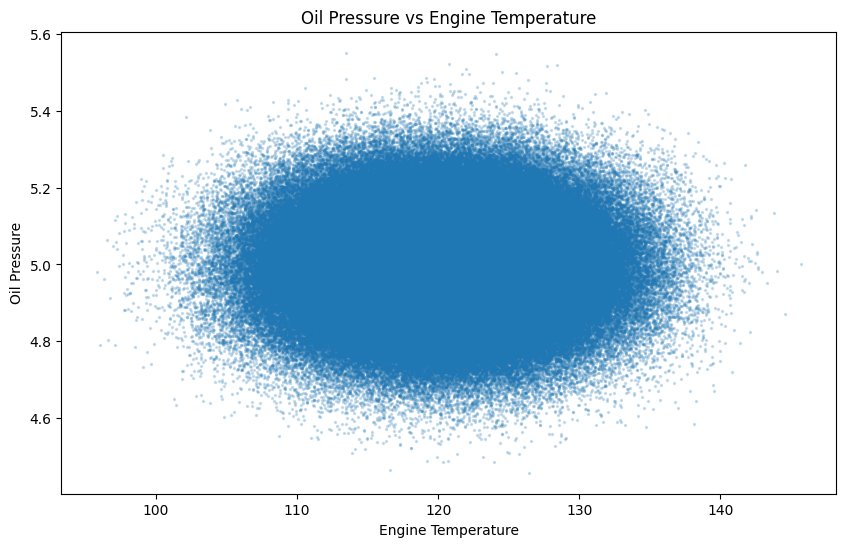

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["engine_temperature"],
    df["oil_pressure"],
    s=2,
    alpha=0.2
)

plt.xlabel("Engine Temperature")
plt.ylabel("Oil Pressure")
plt.title("Oil Pressure vs Engine Temperature")

plt.show()

In [16]:
df[
    ["engine_temperature", "oil_pressure"]
].corr()

,engine_temperature,oil_pressure
engine_temperature,1.000000,-0.003248
oil_pressure,-0.003248,1.000000


Analysing vibrations in the car 

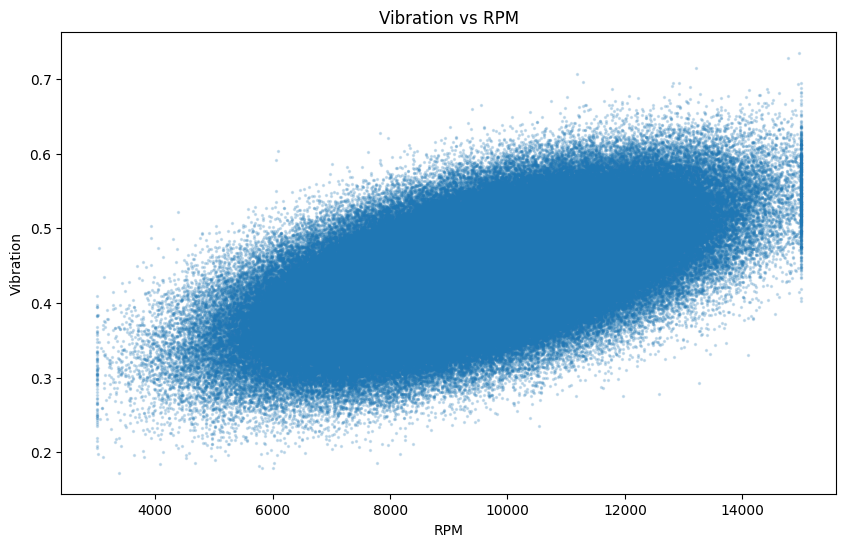

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["rpm"],
    df["vibration"],
    s=2,
    alpha=0.2
)

plt.xlabel("RPM")
plt.ylabel("Vibration")
plt.title("Vibration vs RPM")

plt.show()

In [19]:
df[
    ["rpm", "vibration"]
].corr()

,rpm,vibration
rpm,1.00000,0.58452
vibration,0.58452,1.00000


making the overall correlation matrix for all the features in the dataset
    

In [20]:
telemetry_columns = [
    "rpm",
    "torque",
    "power_output",
    "engine_temperature",
    "oil_temperature",
    "oil_pressure",
    "coolant_temperature",
    "fuel_flow",
    "battery_voltage",
    "battery_current",
    "motor_temperature",
    "vibration",
    "ambient_temperature"
]

correlation_matrix = df[
    telemetry_columns
].corr()

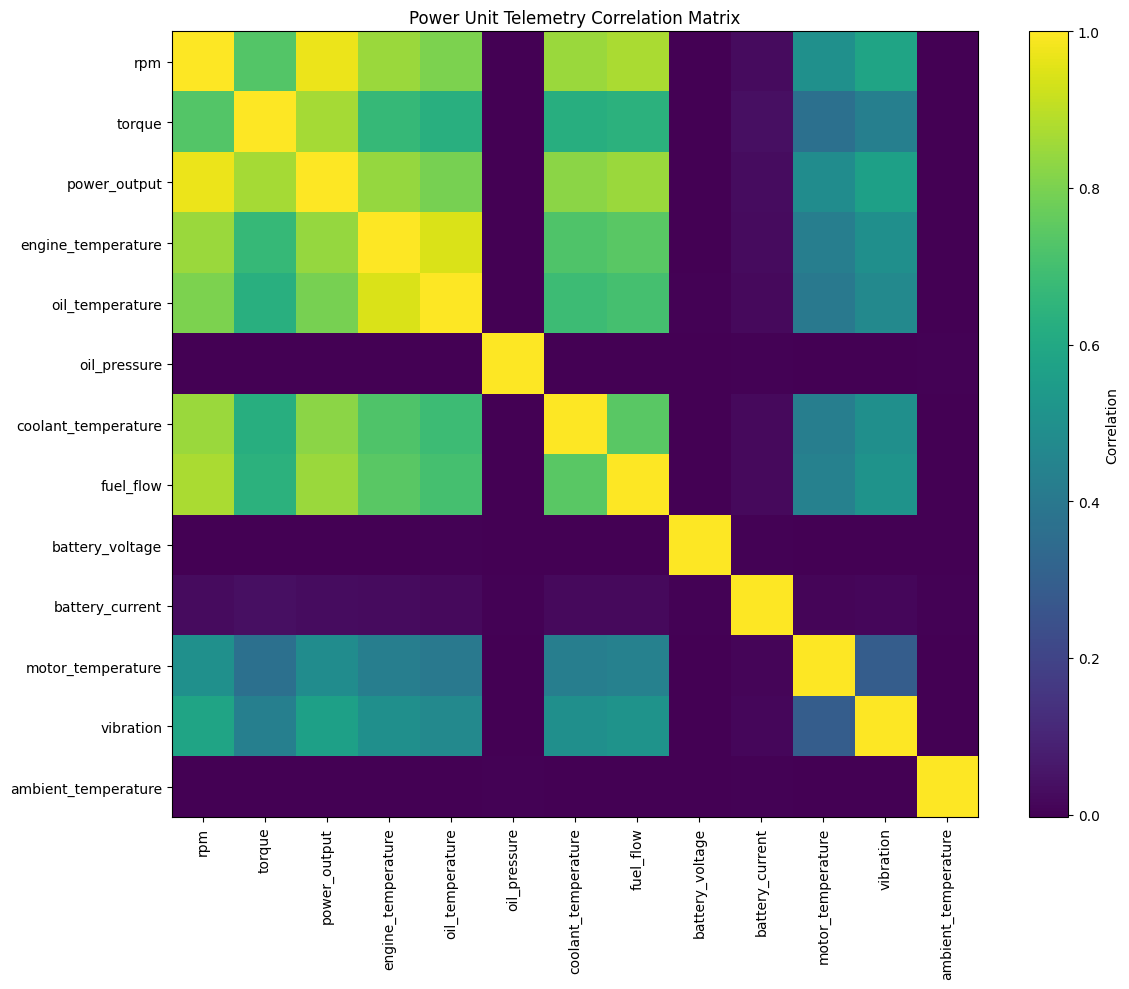

In [21]:
plt.figure(figsize=(12, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(telemetry_columns)),
    telemetry_columns,
    rotation=90
)

plt.yticks(
    range(len(telemetry_columns)),
    telemetry_columns
)

plt.colorbar(label="Correlation")

plt.title("Power Unit Telemetry Correlation Matrix")

plt.tight_layout()

plt.show()

## Initial Observations from this analysis

The correlation analysis was applied to explore the association between the power- unit telemetry variables, which require additional engineering investigation.
The variables identified as strongly correlated do not necessarily have a causal relationship. The findings of this analysis may be considered as hypotheses that can be further explored and validated in subsequent studies.
The emphasis was placed on the relationships between:

- RPM and power
- RPM and temperature
- Engine Temperature and oil pressure
- RPM and vibration